## MARS-S2L *end-to-end* example [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UNEP-IMEO-MARS/marss2l/blob/main/notebooks/examples/download_and_inference.ipynb)

* **Last Modified**: 16-12-2025
* **Author**: Gonzalo Mateo-García
---

## Overview

This notebook demonstrates an *end-to-end* example of the UNEP IMEO pipeline for detecting methane plumes in Sentinel‑2 and Landsat imagery.

Specifically, it shows how to:
1. Download a Sentinel‑2 or Landsat scene.
2. Compute the multi‑band, multi‑pass (MBMP) retrieval [(Irakullis‑Loitxate et al., 2022)](https://doi.org/10.1021/acs.est.1c04873).
3. Run inference with the MARS‑S2L model [(Allen et al., 2025)](https://arxiv.org/abs/2511.21777).
4. Quantify the retrieval ΔXCH₄ and estimate the flux rate of detected plumes [(Gorroño et al., 2023)](https://amt.copernicus.org/articles/16/89/2023/).

### Important

- The MARS‑S2L model produce false positives. In  [(Allen et al., 2025)](https://arxiv.org/abs/2511.21777), we report a 8\% false positive rate.
- Therefore any positive model output must be validated before its use. 
- <u>**At UNEP IMEO, all plumes are manually validated by at least two independent remote sensing analysts before their publication.**</u>
- The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)
-  The *MARS-S2L* database, trained models and tutorials in this package are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt)

**Note**: This notebook requires a [Google Earth Engine](https://earthengine.google.com/) account to download Sentinel-2 or Landsat images.

### Install `marss2l` package

```bash
pip install marss2l
```

## Initialize GEE and choose location and image to run

In [1]:
import pandas as pd
from marss2l.mars_sentinel2 import s2lutils
from marss2l.mars_sentinel2 import ee

from marss2l.utils import setup_stream_logger

ee.ee_initialize()
logger = setup_stream_logger()

/home/gonzalo/mambaforge/envs/marss2ltacopy312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using service account for EE


In [3]:
from datetime import datetime, timezone
lon = -102.13013
lat = 32.16492

tile = "S2B_MSIL1C_20250529T172859_N0511_R055_T13SGR_20250529T210525"
satellite = tile.split("_")[0]
tile_date_str = tile.split("_")[2]
tile_date = datetime.strptime(tile_date_str,"%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

background_image_tile = "S2C_MSIL1C_20250524T172921_N0511_R055_T13SGR_20250524T215704"
satellite_bg = background_image_tile.split("_")[0]
tile_date_bg_str = background_image_tile.split("_")[2]
tile_date_bg = datetime.strptime(tile_date_bg_str,"%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
offshore = False

## Download the current image and the background image

In [4]:
polygon = s2lutils.center_polygon_meters(lon, lat, margin_meters=2_000)

# Download image
image, cloudmask, sza, vza, band_names = s2lutils.download_image_and_angles(tile=tile,
                                                                            satellite=satellite, 
                                                                            geometry=polygon, logger=logger)

# Download background image
image_bg, cloudmask_bg, sza_bg, vza_bg, band_names_bg = s2lutils.download_image_and_angles(tile=background_image_tile,
                                                                                           satellite=satellite_bg, 
                                                                                           geometry=polygon, logger=logger)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


## Download the wind from NASA GEOS FP

In [5]:
from marss2l.mars_sentinel2 import wind

windu, windv = wind.download_wind_nasa_geos_fp((lon, lat), tile_date)

File GEOS.fp.asm.tavg1_2d_slv_Nx.20250529_1730.V01.nc4 exists. It won't be downloaded again


### Plot downloaded data

<Axes: title={'center': 'S2C 20250524T172921'}>

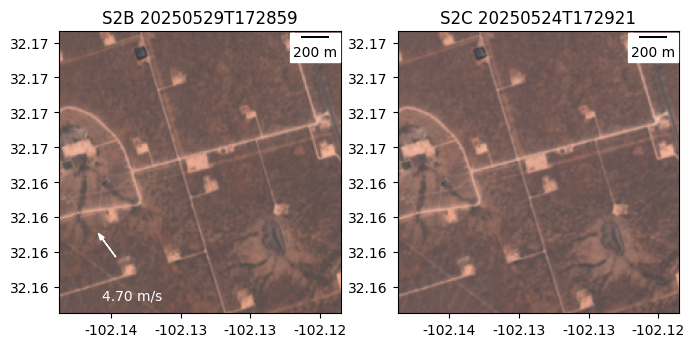

In [6]:
from georeader import plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(8, 4))
rgb = (image.isel({"band": [3, 2, 1]})/4_500).clip(0,1)
rgb_bg = (image_bg.isel({"band": [3, 2, 1]})/4_500).clip(0,1)

title= f"{satellite} {tile_date_str}"
title_bg= f"{satellite_bg} {tile_date_bg_str}"

plot.show(rgb,ax=ax[0],title=title, add_scalebar=True)
wind.add_wind_to_plot([windu,windv], ax=ax[0])
plot.show(rgb_bg,ax=ax[1],title=title_bg, add_scalebar=True)

## Compute MBMP retrieval



/home/gonzalo/mambaforge/envs/marss2ltacopy312/lib/python3.12/site-packages/satalign/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


<Axes: >

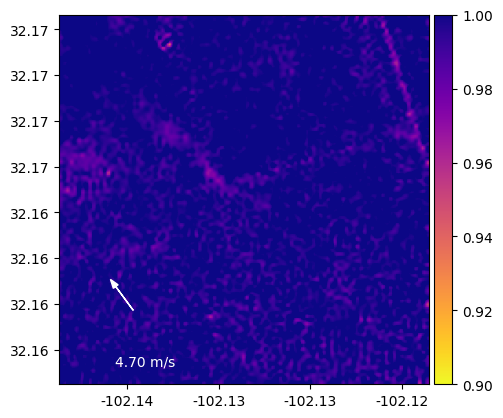

In [7]:
from marss2l.mars_sentinel2 import mixing_ratio_methane
from georeader import rasterize
from georeader.geotensor import GeoTensor
import numpy as np

islandsat = not satellite.startswith("S2")
b11_index = band_names.index("B06") if islandsat else band_names.index("B11")
b12_index = band_names.index("B07") if islandsat else band_names.index("B12")

# validmask
validmask = GeoTensor(cloudmask.values != 4, 
                      crs=cloudmask.crs, transform=cloudmask.transform, fill_value_default=False)

if not offshore:
    mbmp = mixing_ratio_methane.ratio_IL(image,image_bg,
                                         b11_index=b11_index, b12_index=b12_index,
                                         fill_value_ratio_il=1,
                                         validmask=validmask,
                                         corregister=True)
else:
    mbmp = mixing_ratio_methane.ratio_bands(
                image,
                numerator_index=b12_index,
                denominator_index=b11_index,
                validmask=validmask,
                fill_value_default=1,
            )
    

ax = plot.show(mbmp, vmin=0.9, vmax=1, cmap="plasma_r", add_colorbar_next_to=True)
wind.add_wind_to_plot([windu,windv], ax=ax)

## Run inference with the MARS-S2L model

In [8]:
from marss2l.mars_sentinel2 import plume_detection_model
model = plume_detection_model.load_model(logger=logger)

In [9]:
from marss2l.loaders import BANDS_S2_IN_L8
from marss2l.mars_sentinel2.s2lutils import bands_in_l89, get_channels_to_pred
channels_input = bands_in_l89(BANDS_S2_IN_L8) if islandsat else BANDS_S2_IN_L8
channels_input

['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

In [15]:
image_predict = get_channels_to_pred(image, channels=band_names, channels_model=channels_input)
image_predict_bg = get_channels_to_pred(image_bg, channels=band_names_bg, channels_model=channels_input)
binary_mask, scene_score, is_plume, continuous_pred = model.predict(image_predict=image_predict,
                                                                    background_image=image_predict_bg,
                                                                    validmask=validmask,
                                                                    wind_vector=[windu, windv])
logger.info(f"Model score for image {title} is {scene_score:.4f}")

2025-12-16 18:06:45,985 - marss2l.utils - INFO - Model score for image S2B 20250529T172859 is 0.9994


<Axes: title={'center': 'Pixel prob.'}>

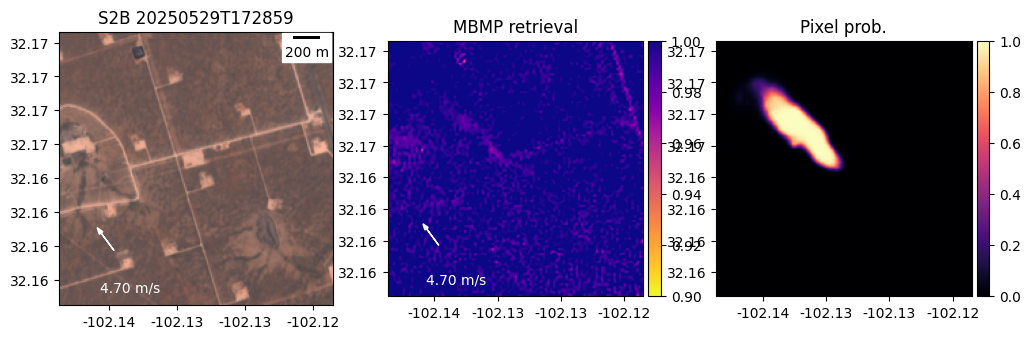

In [17]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
plot.show(rgb,ax=ax[0],title=title, add_scalebar=True)
wind.add_wind_to_plot([windu,windv], ax=ax[0])
plot.show(mbmp, vmin=0.9, vmax=1, cmap="plasma_r", add_colorbar_next_to=True, ax=ax[1], title="MBMP retrieval")
wind.add_wind_to_plot([windu,windv], ax=ax[1])
plot.show(continuous_pred, vmin=0, vmax=1, cmap="magma", add_colorbar_next_to=True, ax=ax[2], title="Pixel prob.")

## Compute the methane concentration image $\Delta$XCH$_4$ and the fluxrate

Fluxrate of image S2B 20250529T172859: 6.22 ± 2.41 t/h


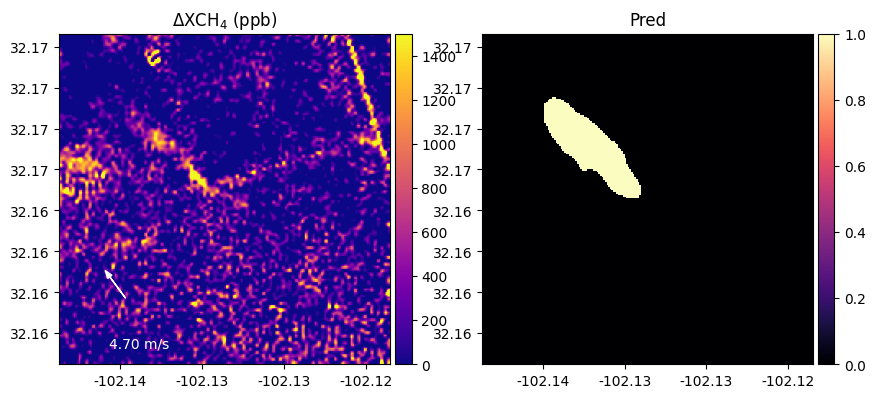

In [29]:
from marss2l.mars_sentinel2 import transmittance_to_ch4, quantification
import math

ch42tr = transmittance_to_ch4.TransmittanceCH4InterpolationFromDict()
ch4 = ch42tr.deltach4_from_ratio_transmittance(satellite=satellite,
                                               sza=sza, vza=vza,
                                               ratio_il=mbmp)

fig, ax = plt.subplots(1,2, figsize=(10, 4.5))
plot.show(ch4, vmin=0, vmax=1_500, cmap="plasma", add_colorbar_next_to=True,title=r"$\Delta$XCH$_4$ (ppb)",ax=ax[0])
wind.add_wind_to_plot([windu,windv], ax=ax[0])

if is_plume:
    qoutput = quantification.obtain_flux_rate(ch4, binary_mask, wind_speed=math.sqrt(windu**2+windv**2),return_std= True)
    plot.show(binary_mask, vmin=0, vmax=1, cmap="magma", add_colorbar_next_to=True, ax=ax[1], title="Pred", interpolation="nearest")
    print(f"Fluxrate of image {title}: {qoutput['Q']/1_000:.2f} ± {qoutput['sigma_Q']/1_000:.2f} t/h")

## Licence
The `marss2l` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *MARS-S2L* database and all pre-trained models are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the models and data in comercial pipelines written consent by UNEP IMEO must be provided.

`marss2l` tutorials and notebooks are released under a [Creative Commons non-commercial share-alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt).

If you find this work useful please cite:

```bibtex
@article{allen_2025,
title = {Artificial intelligence for methane detection: from continuous monitoring to verified mitigation},
author = {Allen, Anna and Mateo-Garcia, Gonzalo and Irakulis-Loitxate, Itziar and Martin, Manuel Montesino-San and Watine, Marc and Requeima, James and Gorroño, Javier and Randles, Cynthia and Mokalled, Tharwat and Guanter, Luis and Turner, Richard E. and Cifarelli, Claudio and Caltagirone, Manfredi},
url = {http://arxiv.org/abs/2511.21777},
doi = {10.48550/arXiv.2511.21777},
month = nov,
year = {2025}
}

```